This time, we focus on a small set of papers from 2021-- and draw the figures needed for the paper.

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [38]:
CAMBRIDGE_COLORS = {
    # Core palette
    "cambridge_blue": "#8EE8D8",
    "cambridge_light_blue": "#D1F9F1",
    "cambridge_warm_blue": "#00BDB6",
    "cambridge_dark_blue": "#133844",
    # Crest series
    "light_crest": "#FFE2C8",
    "warm_crest": "#FFC392",
    "crest": "#FD8153",
    "dark_crest": "#DD3025",
    # Cherry series
    "light_cherry": "#F2CAD8",
    "warm_cherry": "#E18AAC",
    "cherry": "#CD3572",
    "dark_cherry": "#911449",
    # Purple series
    "light_purple": "#F2ECF8",
    "warm_purple": "#D1B7EB",
    "purple": "#A368DF",
    "dark_purple": "#681FB1",
    # Indigo series
    "light_indigo": "#EBEDFB",
    "warm_indigo": "#B0B9F1",
    "indigo": "#5366E0",
    "dark_indigo": "#29347A",
    # Green series
    "light_green": "#DFF2EA",
    "warm_green": "#AFDFCB",
    "green": "#4DB78C",
    "dark_green": "#13553A",
    # Greyscale
    "white": "#FFFFFF",
    "slate_1": "#ECEEF1",
    "slate_2": "#B5BDC8",
    "slate_3": "#546072",
    "slate_4": "#232830",
    # Heritage & special
    "heritage_blue": "#85B09A",
    "judge_yellow": "#ffb81c",
}

# Use TeX fonts with Times New Roman
plt.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{mathptmx}",  # Times font for math and text
        "font.family": "serif",
        "font.serif": ["Times"],
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
        "font.size": 12,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

In [20]:
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./outputs/2026-02-12-figures-for-paper")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [21]:
df = pd.read_csv(DATA_DIR / "interventions_dataset.csv")

## Tokenizer Fertility vs Common Crawl Percentage

In [ ]:
# Load language resourceness data
lang_df = pd.read_csv(DATA_DIR / "tokenizer_fertility" / "language_resourceness.csv")

# Load tokenizer fertility data for each model
fertility_dir = DATA_DIR / "tokenizer_fertility"
model_files = [
    f for f in fertility_dir.glob("*.csv") if f.name != "language_resourceness.csv"
]

# Create a combined dataframe with all models
fertility_dfs = []
for model_file in model_files:
    model_name = model_file.stem.replace("___", "/")
    model_df = pd.read_csv(model_file)
    model_df["model"] = model_name
    fertility_dfs.append(model_df)

fertility_df = pd.concat(fertility_dfs, ignore_index=True)

# Merge with language data
merged_df = fertility_df.merge(lang_df, on="subset", how="left")

# Remove languages not in Common Crawl
merged_df = merged_df[merged_df["commoncrawl_percentage"] > 0]

# Extract script from subset (e.g., "eng_Latn" -> "Latn")
merged_df["script"] = merged_df["subset"].str.extract(r"_([A-Za-z]+)")

# Filter to Latin-script languages only
merged_df = merged_df[merged_df["script"] == "Latn"]

# Remove outliers: filter out languages with fertility > 95th percentile
tpw_95 = merged_df["tpw"].quantile(0.95)
merged_df = merged_df[merged_df["tpw"] <= tpw_95]

print(
    f"Languages after filtering (Latin-script, no outliers): {merged_df['subset'].nunique()}"
)
print(f"Language families: {merged_df['lang_family'].nunique()}")
print(f"\nLanguages per resource level:")
print(merged_df.groupby("lang2tax")["subset"].nunique())

Languages after filtering (Latin-script, no outliers): 83
Language families: 13

Languages per resource level:
lang2tax
0     4
1    35
2    11
3    15
4    13
5     5
Name: subset, dtype: int64


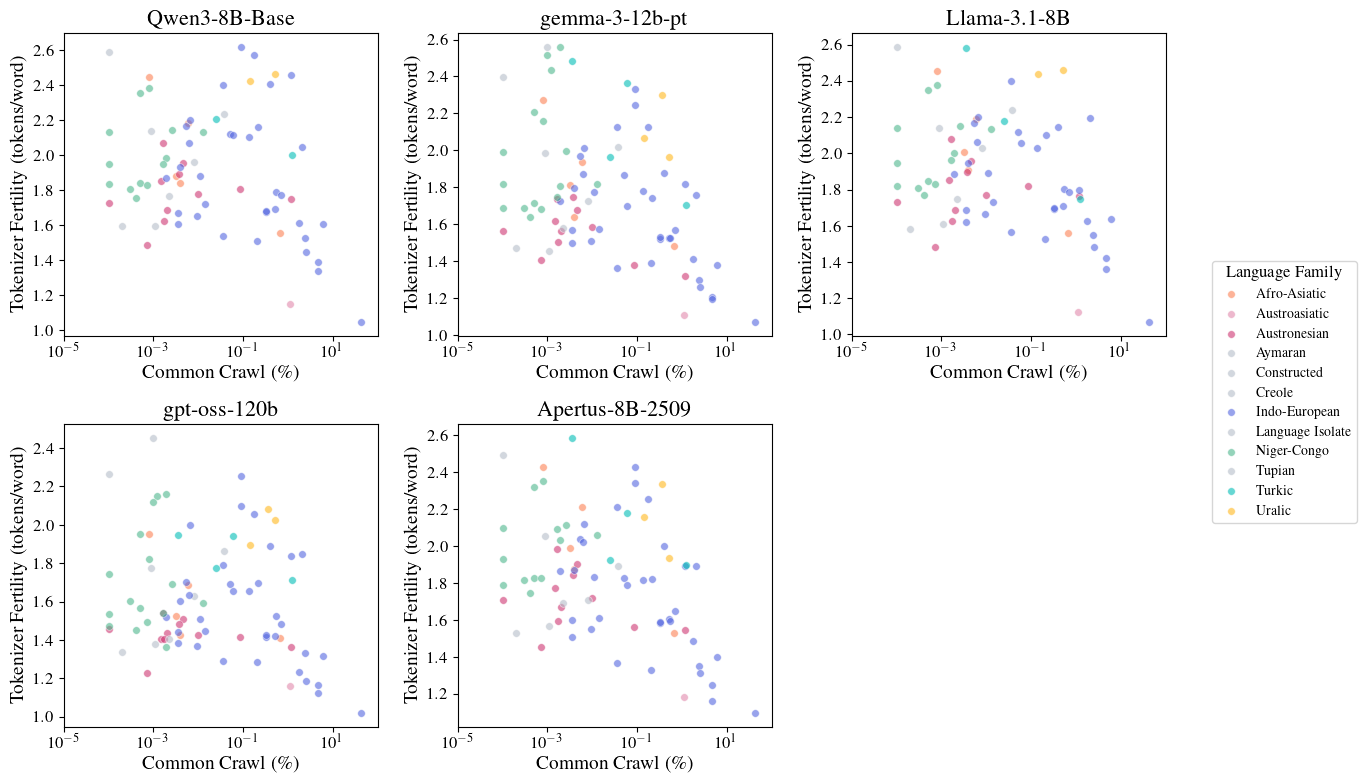

In [23]:
# Get unique models and language families
models = sorted(merged_df["model"].unique())
lang_families = sorted(merged_df["lang_family"].dropna().unique())

# Create a color palette for language families
family_colors = {
    "Indo-European": CAMBRIDGE_COLORS["indigo"],
    "Afro-Asiatic": CAMBRIDGE_COLORS["crest"],
    "Niger-Congo": CAMBRIDGE_COLORS["green"],
    "Austronesian": CAMBRIDGE_COLORS["cherry"],
    "Sino-Tibetan": CAMBRIDGE_COLORS["purple"],
    "Turkic": CAMBRIDGE_COLORS["cambridge_warm_blue"],
    "Uralic": CAMBRIDGE_COLORS["judge_yellow"],
    "Dravidian": CAMBRIDGE_COLORS["dark_crest"],
    "Austroasiatic": CAMBRIDGE_COLORS["warm_cherry"],
    "Tai-Kadai": CAMBRIDGE_COLORS["warm_purple"],
}
# Default color for other families
default_color = CAMBRIDGE_COLORS["slate_2"]

# Create faceted scatter plot
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), squeeze=False)
axes = axes.flatten()

for idx, model in enumerate(models):
    ax = axes[idx]
    model_data = merged_df[merged_df["model"] == model]

    # Plot each language family
    for family in lang_families:
        family_data = model_data[model_data["lang_family"] == family]
        if len(family_data) > 0:
            color = family_colors.get(family, default_color)
            ax.scatter(
                family_data["commoncrawl_percentage"],
                family_data["tpw"],
                c=color,
                label=family if idx == 0 else "",
                alpha=0.6,
                s=30,
                edgecolors="white",
                linewidths=0.5,
            )

    ax.set_xlabel("Common Crawl (\%)")
    ax.set_ylabel("Tokenizer Fertility (tokens/word)")
    ax.set_title(model.split("/")[-1])
    ax.set_xscale("log")
    ax.set_xlim(1e-5, 100)

# Hide empty subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

# Add legend to the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.15, 0.5),
    title="Language Family",
    fontsize=10,
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tokenizer_fertility_vs_cc.pdf", bbox_inches="tight", dpi=300)
plt.show()

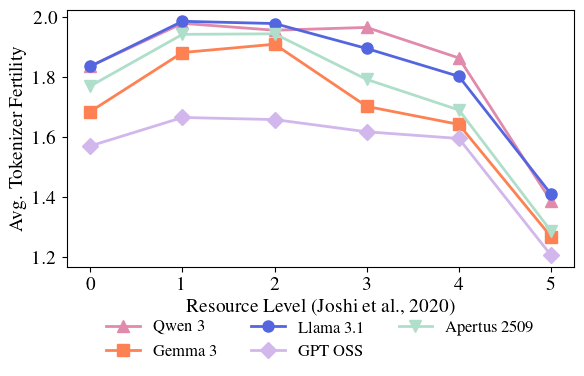

In [67]:
# Compute average tpw per model and lang2tax level
avg_fertility = merged_df.groupby(["model", "lang2tax"])["tpw"].mean().reset_index()

# Create color, marker, and display name for models (using pastel/warm Cambridge colors)
model_styles = {
    "meta-llama/Llama-3.1-8B": {
        "color": CAMBRIDGE_COLORS["indigo"],
        "marker": "o",
        "name": "Llama 3.1",
    },
    "google/gemma-3-12b-pt": {
        "color": CAMBRIDGE_COLORS["crest"],
        "marker": "s",
        "name": "Gemma 3",
    },
    "Qwen/Qwen3-8B-Base": {
        "color": CAMBRIDGE_COLORS["warm_cherry"],
        "marker": "^",
        "name": "Qwen 3",
    },
    "openai/gpt-oss-120b": {
        "color": CAMBRIDGE_COLORS["warm_purple"],
        "marker": "D",
        "name": "GPT OSS",
    },
    "swiss-ai/Apertus-8B-2509": {
        "color": CAMBRIDGE_COLORS["warm_green"],
        "marker": "v",
        "name": "Apertus 2509",
    },
}

fig, ax = plt.subplots(figsize=(6, 4))

for model in sorted(avg_fertility["model"].unique()):
    model_data = avg_fertility[avg_fertility["model"] == model].sort_values("lang2tax")
    style = model_styles.get(
        model, {"color": CAMBRIDGE_COLORS["slate_3"], "marker": "o", "name": model}
    )
    ax.plot(
        model_data["lang2tax"],
        model_data["tpw"],
        marker=style["marker"],
        linewidth=2,
        markersize=8,
        label=style["name"],
        color=style["color"],
    )

ax.set_xlabel("Resource Level (Joshi et al., 2020)")
ax.set_ylabel("Avg. Tokenizer Fertility")
ax.set_xticks(range(6))

# Legend below x-axis, 5 columns
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "tokenizer_fertility_by_resource_level.pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

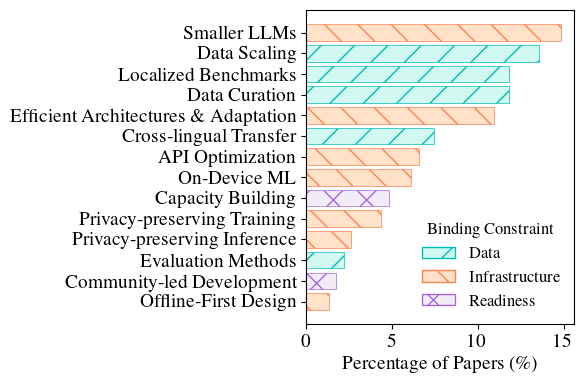

In [59]:
# Load interventions dataset
interventions_df = pd.read_csv(DATA_DIR / "interventions_dataset.csv")

# Fix intervention names: swap Data Curation and Data Scaling
intervention_mapping = {
    "Data Curation": "Data Scaling",
    "Data Scaling": "Data Curation",
    "Data Curation; Data Scaling": "Data Scaling",
}
interventions_df["intervention"] = interventions_df["intervention"].replace(
    intervention_mapping
)

# Count interventions and get binding constraint for each
intervention_counts = (
    interventions_df.groupby(["intervention", "binding_constraint"])
    .size()
    .reset_index(name="count")
)
intervention_totals = (
    intervention_counts.groupby("intervention")["count"]
    .sum()
    .sort_values(ascending=True)
)

# Convert to percentages
total_papers = intervention_totals.sum()
intervention_pct = (intervention_totals / total_papers) * 100

# Colors and subtle hatches by binding constraint (using darker Cambridge colors for hatches)
constraint_styles = {
    "Data": {
        "color": "#D1F9F1",
        "hatch": "/",
        "hatch_color": CAMBRIDGE_COLORS["cambridge_warm_blue"],
    },
    "Infrastructure": {
        "color": "#FFE2C8",
        "hatch": "\\",
        "hatch_color": CAMBRIDGE_COLORS["crest"],
    },
    "Readiness": {
        "color": "#F2ECF8",
        "hatch": "x",
        "hatch_color": CAMBRIDGE_COLORS["purple"],
    },
}

# Get the dominant binding constraint for each intervention (for coloring)
dominant_constraint = interventions_df.groupby("intervention")[
    "binding_constraint"
].agg(lambda x: x.value_counts().index[0])


# Escape special LaTeX characters in labels
def escape_latex(s):
    return s.replace("&", r"\&").replace("_", r"\_")


fig, ax = plt.subplots(figsize=(6, 4))

# Create horizontal bar chart with black edge
bars = ax.barh(
    range(len(intervention_pct)),
    intervention_pct.values,
    color=[
        constraint_styles.get(dominant_constraint[i], {"color": "#CCCCCC"})["color"]
        for i in intervention_pct.index
    ],
    edgecolor="black",
    linewidth=0.5,
)

# Add hatches with darker colors to each bar
for bar, intervention in zip(bars, intervention_pct.index):
    constraint = dominant_constraint[intervention]
    style = constraint_styles.get(constraint, {"hatch": "", "hatch_color": "black"})
    bar.set_hatch(style["hatch"])
    bar.set_edgecolor(style["hatch_color"])

ax.set_yticks(range(len(intervention_pct)))
ax.set_yticklabels([escape_latex(label) for label in intervention_pct.index])
ax.set_xlabel(r"Percentage of Papers (\%)")
ax.set_ylabel("")

# Add legend with matching hatch colors
from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor="#D1F9F1",
        edgecolor=CAMBRIDGE_COLORS["cambridge_warm_blue"],
        hatch="/",
        label="Data",
    ),
    Patch(
        facecolor="#FFE2C8",
        edgecolor=CAMBRIDGE_COLORS["crest"],
        hatch="\\",
        label="Infrastructure",
    ),
    Patch(
        facecolor="#F2ECF8",
        edgecolor=CAMBRIDGE_COLORS["purple"],
        hatch="x",
        label="Readiness",
    ),
]
ax.legend(
    handles=legend_elements,
    title="Binding Constraint",
    loc="lower right",
    frameon=False,
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "intervention_counts.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Intervention by Compute Capacity (FLOPs)

### Key Sources for Device FLOPs:

**Datacenter GPUs:**
- NVIDIA A100 Datasheet: https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/a100/pdf/nvidia-a100-datasheet-nvidia-us-2188504-web.pdf
- NVIDIA H100 Product Page: https://www.nvidia.com/en-us/data-center/h100/
- NVIDIA Ada Architecture Whitepaper (RTX 4090): https://images.nvidia.com/aem-dam/Solutions/geforce/ada/nvidia-ada-gpu-architecture.pdf

**TPUs:**
- Google Cloud TPU v4 Documentation: https://cloud.google.com/tpu/docs/v4
- Google Cloud TPU v5p Documentation: https://cloud.google.com/tpu/docs/v5p

**Apple Silicon:**
- Apple M1 Wikipedia (cites Apple specs): https://en.wikipedia.org/wiki/Apple_M1
- Apple M2 Wikipedia: https://en.wikipedia.org/wiki/Apple_M2

**Mobile/Edge:**
- Apple A17 Pro Wikipedia: https://en.wikipedia.org/wiki/Apple_A17
- Qualcomm Snapdragon 8 Gen 3: https://www.qualcomm.com/products/mobile/snapdragon/smartphones/snapdragon-8-series-mobile-platforms/snapdragon-8-gen-3-mobile-platform
- NVIDIA Jetson Orin Nano: https://developer.nvidia.com/embedded/learn/jetson-orin-nano-devkit-user-guide/hardware_spec.html

**SBC/Embedded:**
- Raspberry Pi 5 HPL Benchmark: https://forums.raspberrypi.com/viewtopic.php?t=358804

**Note:** TOPS (Tera Operations Per Second) typically refers to INT8 operations, while TFLOPS refers to floating-point. For NPU-heavy devices, we use `tflops_equiv` as a rough FP16 equivalent.

In [73]:
# Device FLOPs mapping with sources for compute capacity visualization
# Note: TOPS = INT8 operations, TFLOPS = floating-point. We use TFLOPS (FP16/FP32) where possible.
# For AI accelerators (NPUs), TOPS is more common - we note this in the dict.

DEVICE_FLOPS = {
    # Datacenter GPUs - NVIDIA official datasheets
    "GPU (A100)": {
        "tflops": 312,  # FP16 Tensor
        "source": "https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/a100/pdf/nvidia-a100-datasheet-nvidia-us-2188504-web.pdf",
        "notes": "FP16 Tensor Core, 80GB variant",
    },
    "GPU (H100)": {
        "tflops": 1979,  # FP16 Tensor
        "source": "https://www.nvidia.com/en-us/data-center/h100/",
        "notes": "FP16 Tensor Core",
    },
    "GPU (A100, H100)": {
        "tflops": 1145,  # Average of A100 and H100 for papers testing both
        "source": "NVIDIA datasheets",
        "notes": "Midpoint estimate for papers testing on both",
    },
    # Consumer GPUs - NVIDIA Ada Architecture Whitepaper
    "GPU (RTX 4090)": {
        "tflops": 82.58,  # TF32
        "source": "https://images.nvidia.com/aem-dam/Solutions/geforce/ada/nvidia-ada-gpu-architecture.pdf",
        "notes": "TF32 Tensor Core",
    },
    "GPU (A100, RTX 4090)": {
        "tflops": 197,  # Midpoint
        "source": "NVIDIA datasheets",
        "notes": "Midpoint estimate",
    },
    "GPU (A6000)": {
        "tflops": 38.7,  # FP32
        "source": "NVIDIA RTX A6000 datasheet",
        "notes": "FP32, professional workstation GPU",
    },
    "GPU (A100, A6000)": {
        "tflops": 175,  # Midpoint
        "source": "NVIDIA datasheets",
        "notes": "Midpoint estimate",
    },
    "GPU (RTX 3090)": {
        "tflops": 35.6,  # FP32
        "source": "NVIDIA Ampere whitepaper",
        "notes": "FP32",
    },
    "GPU (A100, RTX 3090)": {
        "tflops": 174,
        "source": "NVIDIA datasheets",
        "notes": "Midpoint estimate",
    },
    "GPU (RTX 8000)": {
        "tflops": 16.3,  # FP32
        "source": "NVIDIA Quadro RTX 8000 datasheet",
        "notes": "FP32, Turing architecture",
    },
    "GPU (V100)": {
        "tflops": 125,  # FP16 Tensor
        "source": "NVIDIA V100 datasheet",
        "notes": "FP16 Tensor Core",
    },
    # TPUs - Google Cloud documentation
    "TPU": {
        "tflops": 275,  # TPU v4
        "source": "https://cloud.google.com/tpu/docs/v4",
        "notes": "TPU v4, BF16",
    },
    "TPUv4": {
        "tflops": 275,
        "source": "https://cloud.google.com/tpu/docs/v4",
        "notes": "BF16",
    },
    # Apple Silicon - Wikipedia, Apple specs
    "Apple Silicon (M1/M2)": {
        "tflops": 3.6,  # M2 10-core GPU
        "source": "https://en.wikipedia.org/wiki/Apple_M1",
        "notes": "M2 GPU, FP32",
    },
    "Apple Silicon (M2 Ultra)": {
        "tflops": 27.2,  # M2 Ultra
        "source": "Apple specifications",
        "notes": "76-core GPU",
    },
    "Apple Silicon": {
        "tflops": 3.6,
        "source": "https://en.wikipedia.org/wiki/Apple_M1",
        "notes": "M2 baseline",
    },
    # Mobile/Edge devices
    "iPhone": {
        "tops": 35,  # A17 Pro Neural Engine
        "tflops_equiv": 2.0,  # Rough FP16 equivalent estimate
        "source": "https://en.wikipedia.org/wiki/Apple_A17",
        "notes": "A17 Pro Neural Engine, 35 TOPS INT8",
    },
    "iPhone 14 (A16 Bionic)": {
        "tops": 17,
        "tflops_equiv": 1.0,
        "source": "Apple specifications",
        "notes": "Neural Engine",
    },
    "iPhone 15 Pro": {
        "tops": 35,
        "tflops_equiv": 2.0,
        "source": "https://en.wikipedia.org/wiki/Apple_A17",
        "notes": "A17 Pro Neural Engine",
    },
    # NVIDIA Edge devices - NVIDIA datasheets
    "NVIDIA Orin": {
        "tops": 275,  # AGX Orin
        "tflops_equiv": 67,  # FP16
        "source": "https://www.nvidia.com/en-us/autonomous-machines/embedded-systems/jetson-orin/",
        "notes": "Jetson AGX Orin",
    },
    "Jetson Orin Nano (8GB)": {
        "tops": 40,
        "tflops_equiv": 10,
        "source": "https://developer.nvidia.com/embedded/learn/jetson-orin-nano-devkit-user-guide/hardware_spec.html",
        "notes": "40 sparse TOPS",
    },
    # Mobile phones (Android)
    "smartphone (Android)": {
        "tops": 45,  # Snapdragon 8 Gen 3 estimate
        "tflops_equiv": 3.0,
        "source": "https://www.qualcomm.com/products/mobile/snapdragon/smartphones/snapdragon-8-series-mobile-platforms/snapdragon-8-gen-3-mobile-platform",
        "notes": "Snapdragon 8 Gen 3 Hexagon NPU estimate",
    },
    "mobile (Pixel 7)": {
        "tops": 7.5,  # Tensor G2
        "tflops_equiv": 1.5,
        "source": "Google Tensor G2 specifications",
        "notes": "Google Tensor G2",
    },
    "mobile (Android/iOS)": {
        "tops": 35,
        "tflops_equiv": 2.0,
        "source": "Various",
        "notes": "Average modern flagship",
    },
    "mobile (iOS/Android)": {
        "tops": 35,
        "tflops_equiv": 2.0,
        "source": "Various",
        "notes": "Average modern flagship",
    },
    # Samsung devices
    "Samsung Galaxy S21 (6GB)": {
        "tops": 15,
        "tflops_equiv": 1.0,
        "source": "Samsung Exynos 2100 specs",
        "notes": "Exynos 2100 NPU",
    },
    "Samsung Galaxy S24 (12GB)": {
        "tops": 45,
        "tflops_equiv": 3.0,
        "source": "Snapdragon 8 Gen 3 specs",
        "notes": "Snapdragon 8 Gen 3",
    },
    "Samsung Galaxy": {
        "tops": 30,
        "tflops_equiv": 2.0,
        "source": "Various",
        "notes": "Average estimate",
    },
    # Edge/SBC devices
    "Raspberry Pi 5": {
        "gflops": 30,  # HPL benchmark
        "tflops_equiv": 0.03,
        "source": "https://forums.raspberrypi.com/viewtopic.php?t=358804",
        "notes": "HPL benchmark ~25-30 GFLOPS",
    },
    # Microcontrollers
    "microcontrollers": {
        "mflops": 100,  # Rough estimate for Cortex-M7 class
        "tflops_equiv": 0.0001,
        "source": "ARM Cortex-M7 specifications",
        "notes": "Order of magnitude estimate",
    },
    "embedded devices": {
        "mflops": 500,
        "tflops_equiv": 0.0005,
        "source": "Various embedded specs",
        "notes": "Rough estimate",
    },
    # CPU-only
    "CPU": {
        "tflops": 0.5,  # Modern desktop CPU rough estimate
        "source": "Various benchmarks",
        "notes": "Single modern CPU, FP32 estimate",
    },
    # Browser (WebGPU)
    "browser (WebGPU)": {
        "tflops": 5.0,  # Depends heavily on client GPU
        "source": "Varies by client hardware",
        "notes": "Highly variable, estimate for mid-range GPU",
    },
    "browser": {"tflops": 5.0, "source": "Varies", "notes": "Estimate"},
    # GPU generic
    "GPU": {
        "tflops": 50,  # Generic mid-range estimate
        "source": "Various",
        "notes": "Generic estimate",
    },
}

print(f"Defined FLOPS mapping for {len(DEVICE_FLOPS)} device categories")

Defined FLOPS mapping for 35 device categories


In [ ]:
import ast
import numpy as np

# Load the interventions dataset
interventions_df = pd.read_csv(DATA_DIR / "interventions_dataset.csv")


# Parse devices_tested column (it's a string representation of a list)
def parse_devices(devices_str):
    """Parse the devices_tested column from string to list."""
    if pd.isna(devices_str) or devices_str == "[]":
        return []
    try:
        return ast.literal_eval(devices_str)
    except:
        return []


interventions_df["devices_list"] = interventions_df["devices_tested"].apply(
    parse_devices
)

# Filter to only rows with non-empty devices_tested
df_with_devices = interventions_df[
    interventions_df["devices_list"].apply(len) > 0
].copy()
print(f"Papers with device info: {len(df_with_devices)} / {len(interventions_df)}")

# Get unique devices to see what we need to map
all_devices = set()
for devices in df_with_devices["devices_list"]:
    all_devices.update(devices)
print(f"\nUnique devices found ({len(all_devices)}):")
for d in sorted(all_devices):
    print(f"  - {d}")

Papers with device info: 65 / 229

Unique devices found (47):
  - AMD GPUs
  - Apple Silicon
  - Apple Silicon (M1/M2)
  - Apple Silicon (M2 Ultra)
  - Apple Silicon MacBooks
  - CPU
  - GPU
  - GPU (A100)
  - GPU (A100, A10G)
  - GPU (A100, A6000)
  - GPU (A100, H100)
  - GPU (A100, RTX 3090)
  - GPU (A100, RTX 4090)
  - GPU (A6000)
  - GPU (H100)
  - GPU (H800)
  - GPU (RTX 8000)
  - GPU (TPUv4)
  - GPU (V100)
  - GPU (single 48GB)
  - Jetson Orin Nano (8GB)
  - NVIDIA A100 48GB
  - NVIDIA GPUs
  - NVIDIA Orin
  - Raspberry Pi 5
  - Samsung Galaxy
  - Samsung Galaxy S21 (6GB)
  - Samsung Galaxy S24 (12GB)
  - Snapdragon phones
  - TPU
  - browser
  - browser (WebGPU)
  - edge
  - embedded devices
  - iPhone
  - iPhone 14 (A16 Bionic)
  - iPhone 15 Pro
  - microcontrollers
  - mobile
  - mobile (Android/iOS)
  - mobile (Pixel 7)
  - mobile (iOS/Android)
  - mobile (iPhone)
  - mobile (simulated)
  - mobile devices
  - smartphone (Android)
  - x86 laptops


In [74]:
# Helper function to get TFLOPS for a device
def get_tflops(device_name):
    """Get TFLOPS value for a device, checking various key formats."""
    # Direct match
    if device_name in DEVICE_FLOPS:
        entry = DEVICE_FLOPS[device_name]
        return entry.get("tflops") or entry.get("tflops_equiv")

    # Try partial matching for common patterns
    device_lower = device_name.lower()

    # Check for GPU patterns
    if "a100" in device_lower and "h100" in device_lower:
        return DEVICE_FLOPS.get("GPU (A100, H100)", {}).get("tflops", 1145)
    elif "h100" in device_lower:
        return DEVICE_FLOPS.get("GPU (H100)", {}).get("tflops", 1979)
    elif "a100" in device_lower:
        return DEVICE_FLOPS.get("GPU (A100)", {}).get("tflops", 312)
    elif "4090" in device_lower or "rtx 4090" in device_lower:
        return DEVICE_FLOPS.get("GPU (RTX 4090)", {}).get("tflops", 82.58)
    elif "a6000" in device_lower:
        return DEVICE_FLOPS.get("GPU (A6000)", {}).get("tflops", 38.7)
    elif "v100" in device_lower:
        return DEVICE_FLOPS.get("GPU (V100)", {}).get("tflops", 125)
    elif "tpu" in device_lower:
        return DEVICE_FLOPS.get("TPU", {}).get("tflops", 275)
    elif (
        "apple silicon" in device_lower or "m1" in device_lower or "m2" in device_lower
    ):
        return DEVICE_FLOPS.get("Apple Silicon (M1/M2)", {}).get("tflops", 3.6)
    elif "iphone" in device_lower:
        return DEVICE_FLOPS.get("iPhone", {}).get("tflops_equiv", 2.0)
    elif "orin" in device_lower:
        return DEVICE_FLOPS.get("Jetson Orin Nano (8GB)", {}).get("tflops_equiv", 10)
    elif "raspberry" in device_lower:
        return DEVICE_FLOPS.get("Raspberry Pi 5", {}).get("tflops_equiv", 0.03)
    elif "microcontroller" in device_lower:
        return DEVICE_FLOPS.get("microcontrollers", {}).get("tflops_equiv", 0.0001)
    elif "mobile" in device_lower or "android" in device_lower or "ios" in device_lower:
        return DEVICE_FLOPS.get("mobile (Android/iOS)", {}).get("tflops_equiv", 2.0)
    elif "browser" in device_lower or "webgpu" in device_lower:
        return DEVICE_FLOPS.get("browser (WebGPU)", {}).get("tflops", 5.0)
    elif "cpu" in device_lower:
        return DEVICE_FLOPS.get("CPU", {}).get("tflops", 0.5)
    elif "gpu" in device_lower:
        return DEVICE_FLOPS.get("GPU", {}).get("tflops", 50)
    elif "samsung" in device_lower or "galaxy" in device_lower:
        return DEVICE_FLOPS.get("Samsung Galaxy", {}).get("tflops_equiv", 2.0)
    elif "pixel" in device_lower:
        return DEVICE_FLOPS.get("mobile (Pixel 7)", {}).get("tflops_equiv", 1.5)
    elif "snapdragon" in device_lower:
        return DEVICE_FLOPS.get("smartphone (Android)", {}).get("tflops_equiv", 3.0)
    elif "embedded" in device_lower:
        return DEVICE_FLOPS.get("embedded devices", {}).get("tflops_equiv", 0.0005)

    print(f"  Warning: No TFLOPS mapping for '{device_name}'")
    return None


# Test the mapping on our devices
print("Testing device -> TFLOPS mapping:")
for device in sorted(all_devices):
    tflops = get_tflops(device)
    print(f"  {device}: {tflops} TFLOPS")

Testing device -> TFLOPS mapping:
  AMD GPUs: 50 TFLOPS
  Apple Silicon: 3.6 TFLOPS
  Apple Silicon (M1/M2): 3.6 TFLOPS
  Apple Silicon (M2 Ultra): 27.2 TFLOPS
  Apple Silicon MacBooks: 3.6 TFLOPS
  CPU: 0.5 TFLOPS
  GPU: 50 TFLOPS
  GPU (A100): 312 TFLOPS
  GPU (A100, A10G): 312 TFLOPS
  GPU (A100, A6000): 175 TFLOPS
  GPU (A100, H100): 1145 TFLOPS
  GPU (A100, RTX 3090): 174 TFLOPS
  GPU (A100, RTX 4090): 197 TFLOPS
  GPU (A6000): 38.7 TFLOPS
  GPU (H100): 1979 TFLOPS
  GPU (H800): 50 TFLOPS
  GPU (RTX 8000): 16.3 TFLOPS
  GPU (TPUv4): 275 TFLOPS
  GPU (V100): 125 TFLOPS
  GPU (single 48GB): 50 TFLOPS
  Jetson Orin Nano (8GB): 10 TFLOPS
  NVIDIA A100 48GB: 312 TFLOPS
  NVIDIA GPUs: 50 TFLOPS
  NVIDIA Orin: 67 TFLOPS
  Raspberry Pi 5: 0.03 TFLOPS
  Samsung Galaxy: 2.0 TFLOPS
  Samsung Galaxy S21 (6GB): 1.0 TFLOPS
  Samsung Galaxy S24 (12GB): 3.0 TFLOPS
  Snapdragon phones: 3.0 TFLOPS
  TPU: 275 TFLOPS
  browser: 5.0 TFLOPS
  browser (WebGPU): 5.0 TFLOPS
  edge: None TFLOPS
  embedded 

In [75]:
# Create expanded dataframe with one row per (paper, device) combination
rows = []
for _, row in df_with_devices.iterrows():
    for device in row["devices_list"]:
        tflops = get_tflops(device)
        if tflops is not None:
            rows.append(
                {
                    "title": row["title"],
                    "intervention": row["intervention"],
                    "binding_constraint": row["binding_constraint"],
                    "device": device,
                    "tflops": tflops,
                }
            )

plot_df = pd.DataFrame(rows)
print(f"Total data points for plot: {len(plot_df)}")
print(f"Unique interventions: {plot_df['intervention'].nunique()}")
print(f"\nTFLOPS range: {plot_df['tflops'].min():.4f} - {plot_df['tflops'].max():.1f}")

# Show distribution
print(f"\nPoints per intervention:")
print(plot_df.groupby("intervention").size().sort_values(ascending=False))

Total data points for plot: 91
Unique interventions: 8

TFLOPS range: 0.0001 - 1979.0

Points per intervention:
intervention
On-Device ML                            31
Smaller LLMs                            26
Efficient Architectures & Adaptation    19
Offline-First Design                     7
API Optimization                         4
Privacy-preserving Training              2
Data Curation                            1
Privacy-preserving Inference             1
dtype: int64


Infrastructure data points: 90
Unique interventions: 7
TFLOPS range in data: 0.0001 - 1979.0


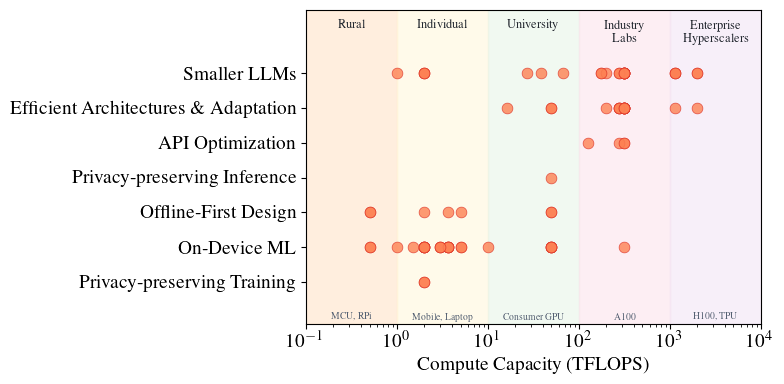

In [90]:
# Create scatter plot: Infrastructure Interventions vs Compute Capacity (TFLOPS)
# With colored background bands for compute tiers

# Filter to Infrastructure only
infra_df = plot_df[plot_df["binding_constraint"] == "Infrastructure"].copy()
print(f"Infrastructure data points: {len(infra_df)}")
print(f"Unique interventions: {infra_df['intervention'].nunique()}")
print(
    f"TFLOPS range in data: {infra_df['tflops'].min():.4f} - {infra_df['tflops'].max():.1f}"
)

# Sort interventions by median TFLOPS
intervention_order = (
    infra_df.groupby("intervention")["tflops"].median().sort_values().index.tolist()
)

# Create intervention to y-position mapping
intervention_to_y = {interv: i for i, interv in enumerate(intervention_order)}
infra_df["y_pos"] = infra_df["intervention"].map(intervention_to_y)

# Add jitter to y-position
np.random.seed(42)
infra_df["y_jitter"] = infra_df["y_pos"] + np.random.uniform(-0.0, 0.0, len(infra_df))

fig, ax = plt.subplots(figsize=(8, 4))

# Define compute tiers - more balanced on log scale
compute_tiers = [
    {
        "name": "Rural",
        "min": 0.1,
        "max": 1,
        "color": "#FFE4C9",
        "devices": "MCU, RPi",
        "y_offset": 0,
    },
    {
        "name": "Individual",
        "min": 1,
        "max": 10,
        "color": "#FFF8DC",
        "devices": "Mobile, Laptop",
        "y_offset": 0,
    },
    {
        "name": "University",
        "min": 10,
        "max": 100,
        "color": "#E8F5E9",
        "devices": "Consumer GPU",
        "y_offset": 0,
    },
    {
        "name": "Industry\nLabs",
        "min": 100,
        "max": 1000,
        "color": "#FCE4EC",
        "devices": "A100",
        "y_offset": -0.4,
    },
    {
        "name": "Enterprise\nHyperscalers",
        "min": 1000,
        "max": 10000,
        "color": "#F3E5F5",
        "devices": "H100, TPU",
        "y_offset": -0.4,
    },
]

# Add colored background bands
for tier in compute_tiers:
    ax.axvspan(tier["min"], tier["max"], alpha=0.6, color=tier["color"], zorder=0)
    mid_x = np.sqrt(tier["min"] * tier["max"])  # Geometric mean for log scale

    # Tier label at top (with offset for multi-line labels)
    ax.text(
        mid_x,
        len(intervention_order) + 0.2 + tier["y_offset"],
        tier["name"],
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=CAMBRIDGE_COLORS["slate_4"],
    )

    # Device examples at bottom
    ax.text(
        mid_x,
        -0.9,
        tier["devices"],
        ha="center",
        va="top",
        fontsize=7,
        fontstyle="italic",
        color=CAMBRIDGE_COLORS["slate_3"],
    )

# Plot the scatter points
ax.scatter(
    infra_df["tflops"],
    infra_df["y_jitter"],
    c=CAMBRIDGE_COLORS["crest"],
    alpha=0.8,
    s=60,
    edgecolors=CAMBRIDGE_COLORS["dark_crest"],
    linewidths=0.5,
    zorder=3,
)

# Set log scale for x-axis
ax.set_xscale("log")
ax.set_xlim(0.1, 10000)

# Set y-ticks to intervention names
ax.set_yticks(range(len(intervention_order)))
ax.set_yticklabels([i.replace("&", r"\&") for i in intervention_order])
ax.set_ylim(-1.2, len(intervention_order) + 0.8)

# Labels
ax.set_xlabel("Compute Capacity (TFLOPS)")
ax.set_ylabel("")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "intervention_by_compute_capacity.pdf", bbox_inches="tight", dpi=300
)
plt.show()